# Linear Regression Model

This notebook is the training and development of the linear regression model. The purpose of this model is to establish a baseline performance for the other models.

In [55]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np 
from sklearn.metrics import  r2_score
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
import matplotlib.dates as mdates

### Weather and water only dataset

In [ ]:
data_folder = Path(r'..\..\data\model-ready\water-weather')

##### read in our model ready data

In [57]:
# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'scaled-Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y = pd.read_parquet(data_folder / 'scaled-Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y = pd.read_parquet(data_folder / 'scaled-Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [58]:
train_X_df.head(2)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp
0,0.430769,0.734694,0.0,0.659722,0.646667,0.545455,0.033333,0.0,0.430769,0.734694,0.25,0.066987,0.697431,0.959375,0.645600,0.096098
1,0.384615,0.673469,0.0,0.659722,0.666667,0.545455,0.066667,0.0,0.384615,0.673469,0.25,0.066987,0.786001,0.910151,0.658933,0.119320


In [59]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

##### train the model

In [60]:
model = LinearRegression()
model.fit(train_X_df, train_y_df)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 16)","[[ 0.5 , 0.35,-0.1 ,...,-0. , 2.19, 0.23]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['TMAX','TMIN','PRCP',...,'cos_day','past_10_day_ave_temp', 'past_10_day_std_temp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[10.51]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


#### evaluate on validation and test dataset
The two sets are combined here, as the validation set it truly needed for training nueral networks, where a validation set is used to prevent overfitting.

In [61]:
test_val_x = pd.concat([test_X_df, val_X_df], ignore_index=True)
test_val_y = pd.concat([test_y, val_y], ignore_index=True)

In [62]:
y_pred = model.predict(test_val_x)

In [63]:
test_val_x_unscaled = scaler.inverse_transform(test_val_x)

In [64]:
test_val_x = pd.DataFrame(columns=test_val_x.columns, data=test_val_x_unscaled)

In [65]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873


In [66]:
test_val_x['date'] = pd.to_datetime(test_val_x[['year','month','day']], errors='coerce')

In [67]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873,2013-01-08


In [68]:
test_val_x['prediction'] = y_pred

In [69]:
test_val_x['target'] = test_val_y

In [70]:
errors = y_pred - test_val_y
test_val_x['errors'] = errors

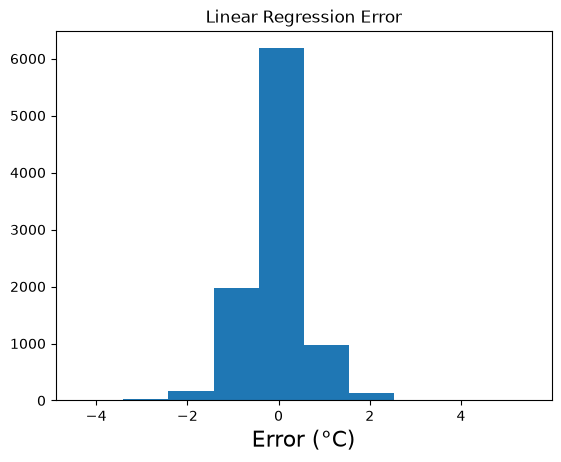

In [71]:
plt.hist(errors)
plt.title('Linear Regression Error')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [72]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date,prediction,target,errors
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873,2013-01-08,13.685843,13.6,0.085843


In [73]:
test_val_x.loc[4440:4449]

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date,prediction,target,errors
4440,61.0,45.0,0.59,13.55,14.2,3.0,6.0,2025.0,16.111111,7.222222,1.0,0.0,0.937752,0.347305,15.185,0.420350,2025-03-06,14.240894,14.1,0.140894
4441,61.0,47.0,0.02,12.50,14.1,3.0,7.0,2025.0,16.111111,8.333333,1.0,0.0,0.988468,0.151428,15.025,0.499583,2025-03-07,14.087521,14.6,-0.512479
4442,66.0,46.0,0.00,14.50,14.6,3.0,8.0,2025.0,18.888889,7.777778,1.0,0.0,0.998717,-0.050649,14.985,0.517499,2025-03-08,14.683634,13.9,0.783634
4443,70.0,45.0,0.00,13.30,13.9,3.0,9.0,2025.0,21.111111,7.222222,1.0,0.0,0.968077,-0.250653,14.845,0.604819,2025-03-09,14.146777,13.7,0.446777
4444,71.0,47.0,0.00,12.50,13.7,3.0,10.0,2025.0,21.666667,8.333333,1.0,0.0,0.897805,-0.440394,14.725,0.703661,2025-03-10,13.962497,13.2,0.762497
4445,62.0,55.0,0.91,12.80,13.2,3.0,11.0,2025.0,16.666667,12.777778,1.0,0.0,0.790776,-0.612106,14.495,0.792482,2025-03-11,13.596194,14.8,-1.203806
4446,63.0,58.0,0.02,14.60,14.8,3.0,12.0,2025.0,17.222222,14.444444,1.0,0.0,0.651372,-0.758758,14.425,0.721592,2025-03-12,14.858307,14.5,0.358307
4447,61.0,52.0,0.75,14.35,14.5,3.0,13.0,2025.0,16.111111,11.111111,1.0,0.0,0.485302,-0.874347,14.340,0.646701,2025-03-13,14.480825,14.1,0.380825
4448,59.0,53.0,0.28,14.10,14.1,3.0,14.0,2025.0,15.000000,11.666667,1.0,0.0,0.299363,-0.954139,14.230,0.573585,2025-03-14,14.183331,13.8,0.383331
4449,64.0,51.0,0.00,13.80,13.8,3.0,15.0,2025.0,17.777778,10.555556,1.0,0.0,0.101168,-0.994869,14.090,0.472464,2025-03-15,13.992122,14.2,-0.207878


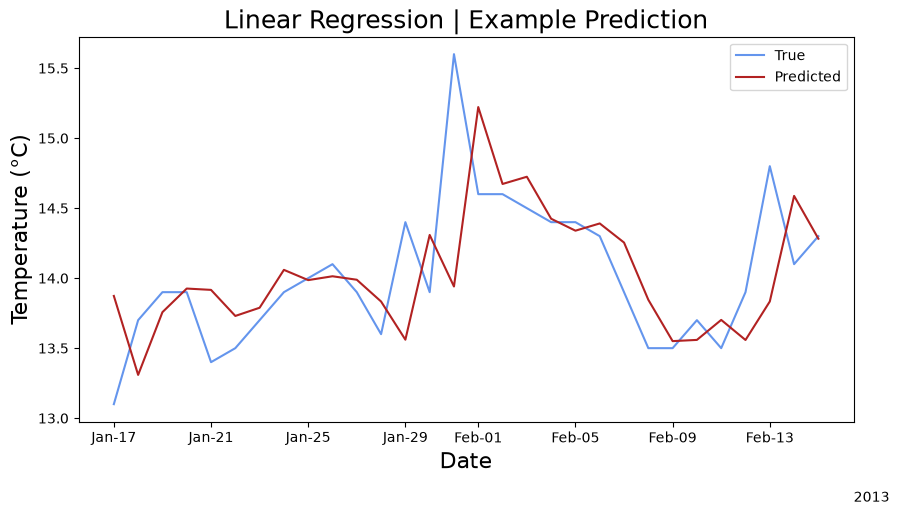

In [74]:
plot_df = test_val_x[9:39].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.target, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.prediction, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Linear Regression | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
fig.text(.9, -.05, f'{int(plot_df.year.unique()[0])}')
plt.show()

In [76]:
mse = np.mean([x**2 for x in errors.target])
rmse = np.sqrt(mse)
r_2 = r2_score(test_val_y, y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.65
r2 score = 0.94


##### Baseline RMSE and R2 Score are 0.65 and 0.94 respectively